In [1]:
import pandas as pd
from pathlib import Path

In [2]:
import plotly.express as px

In [3]:
import plotly.io as pio

In [4]:
# want to make plots visible in GitHub, so using another renderer
# interactive part is lost, if that is needed, uncomment the following
pio.renderers.default = 'svg'


In [5]:
data_folder = Path("../data")
path_csv_ny_marathon = data_folder / "NYC Marathon Results, 2024 - Marathon Runner Results.csv"

In [6]:
df_ny_marathon = pd.read_csv(path_csv_ny_marathon)

In [7]:
df_ny_marathon.head(5)

,runnerId,firstName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount
0,41771195,Abdi,7.0,35,M,Nijmegen,NLD,NaN,NED,1,2:07:39,4:53,1,6:57,1,96.86,4
1,41775746,Evans,3.0,35,M,Kapsabet,KEN,-,KEN,2,2:07:45,4:53,2,7:03,2,96.79,2
2,41766254,Albert,2.0,30,M,Kapkitony,KEN,NaN,KEN,3,2:08:00,4:53,3,8:00,3,96.06,5
3,41763160,Tamirat,1.0,33,M,Addis Ababa,ETH,NaN,ETH,4,2:08:12,4:54,4,8:02,4,96.03,4
4,41757406,Geoffrey,6.0,31,M,Kapchorwa District,KEN,-,KEN,5,2:08:50,4:55,5,8:50,6,95.44,5


In [8]:
df_ny_marathon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55524 entries, 0 to 55523
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   runnerId         55524 non-null  int64  
 1   firstName        55524 non-null  object 
 2   bib              55512 non-null  float64
 3   age              55524 non-null  int64  
 4   gender           55512 non-null  object 
 5   city             55462 non-null  object 
 6   countryCode      55512 non-null  object 
 7   stateProvince    55231 non-null  object 
 8   iaaf             55511 non-null  object 
 9   overallPlace     55524 non-null  int64  
 10  overallTime      55524 non-null  object 
 11  pace             55524 non-null  object 
 12  genderPlace      55524 non-null  int64  
 13  ageGradeTime     55524 non-null  object 
 14  ageGradePlace    55524 non-null  int64  
 15  ageGradePercent  55524 non-null  float64
 16  racesCount       55524 non-null  int64  
dtypes: float64(2

**Some observations**

bib - race number

There are several columns, variables which specifiy the place - like overall place, place by gender, ageGradeOlace.

There are some missing values.

In [9]:
column_nan_count = df_ny_marathon.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
runnerId             0
firstName            0
bib                 12
age                  0
gender              12
city                62
countryCode         12
stateProvince      293
iaaf                13
overallPlace         0
overallTime          0
pace                 0
genderPlace          0
ageGradeTime         0
ageGradePlace        0
ageGradePercent      0
racesCount           0
dtype: int64


### Starting point from plotly figure friday homepage

The following function is the starting point from the code given on the Figure Friday organizers. 

    def convert_pace_to_minutes(pace_str):
        try:
            minutes, seconds = map(int, pace_str.split(':'))
            return minutes + seconds / 60
        except ValueError:
            return None


The idea is to convert the pace column, a string minutes:seconds (per mile) into a float minutes (per mile). Checking NaN again showed that some values couldn't be converted. See below for the last rows of the dataset. Checking the pace column, it shows that the chosen format was different - probably minutes : seconds : miliseconds? Therefore, the function was adapted to rather use if-else statements, to fix this aspect.

Another aspect appeared when the dataset was checked for minimum age - which resulted in the value 0, which seemed not right. Generating a dataframe where age==0, it showed that there are Anonymous runners, for which besides times and places (overall place, etc.) nothing else was given. I decided to drop these which also got rid of NaN in gender, countryCode, bib and iaaf.


In [10]:
df_ny_marathon.tail(5)

,runnerId,firstName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount
55519,41802120,Lay,66580.0,73,W,Auckland,NZL,Auckland,GBR,55520,11:23:55,26:06:00,24707,12:47,24396,31.29,1
55520,41753795,Guillermo,12699.0,71,M,Garza-Garcia,MEX,Nuevo Leon,MEX,55521,11:38:21,26:39:00,30695,28:49:00,30674,24.16,37
55521,41751479,Thomas,12713.0,82,M,Randolph,USA,NJ,USA,55522,11:42:21,26:48:00,30696,56:59:00,30501,29.49,35
55522,41770749,Jill,14443.0,43,W,Chicago,USA,IL,USA,55523,11:43:07,26:50:00,24708,12:19,24709,20.14,1
55523,41770690,Ceil,12888.0,59,W,Long Island City,USA,NY,USA,55524,11:47:55,27:00:00,24709,17:33,24701,24.29,1


In [11]:
min_age = min(df_ny_marathon.age)
min_age

0

In [12]:
df_age_0 = df_ny_marathon[df_ny_marathon['age'] == 0]
print("The length of df_age_0 is: ", len(df_age_0))
print("-----------------------------------------------------")
df_age_0.head()

The length of df_age_0 is:  12
-----------------------------------------------------


,runnerId,firstName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount
2263,41758767,Anonymous,NaN,0,NaN,NaN,NaN,NaN,NaN,2264,3:00:34,6:54,2047,41:07:00,924,76.32,1
16718,41781831,Anonymous,NaN,0,NaN,NaN,NaN,NaN,NaN,16719,3:55:29,8:59,4482,55:29:00,6428,57.51,1
17705,41782412,Anonymous,NaN,0,NaN,NaN,NaN,NaN,NaN,17706,3:57:36,9:04,12807,51:57:00,14788,53.01,1
18199,41757327,Anonymous,NaN,0,NaN,NaN,NaN,NaN,NaN,18200,3:58:33,9:06,13099,32:50:00,9821,57.77,1
27860,41751519,Anonymous,NaN,0,NaN,NaN,NaN,NaN,NaN,27861,4:23:52,10:04,9393,5:26,8303,55.18,1


In [13]:
df_ny_marathon = df_ny_marathon[df_ny_marathon["firstName"] != "Anonymous"]
df_ny_marathon.shape

(55512, 17)

In [14]:
# adapted function

def convert_pace_to_minutes(pace_str):

    if len(pace_str.split(":")) == 2:
        
        minutes, seconds = map(int, pace_str.split(':'))
        return minutes + seconds / 60


    elif len(pace_str.split(":")) == 3:

        minutes, seconds, _ = map(int, pace_str.split(':'))
        return minutes + seconds / 60

    else:

        return None



In [15]:
# Apply conversion to the `pace` column
df_ny_marathon['pace_minutes'] = df_ny_marathon['pace'].apply(convert_pace_to_minutes)


In [16]:
min_age_cleaned = min(df_ny_marathon["age"])
min_age_cleaned

18

In [17]:
max_age_cleaned = max(df_ny_marathon["age"])
max_age_cleaned

88

In [18]:
# Define age groups
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ['10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90']

# Create a new column for age groups
df_ny_marathon['age_group'] = pd.cut(df_ny_marathon['age'], bins=bins, labels=labels, right=False)

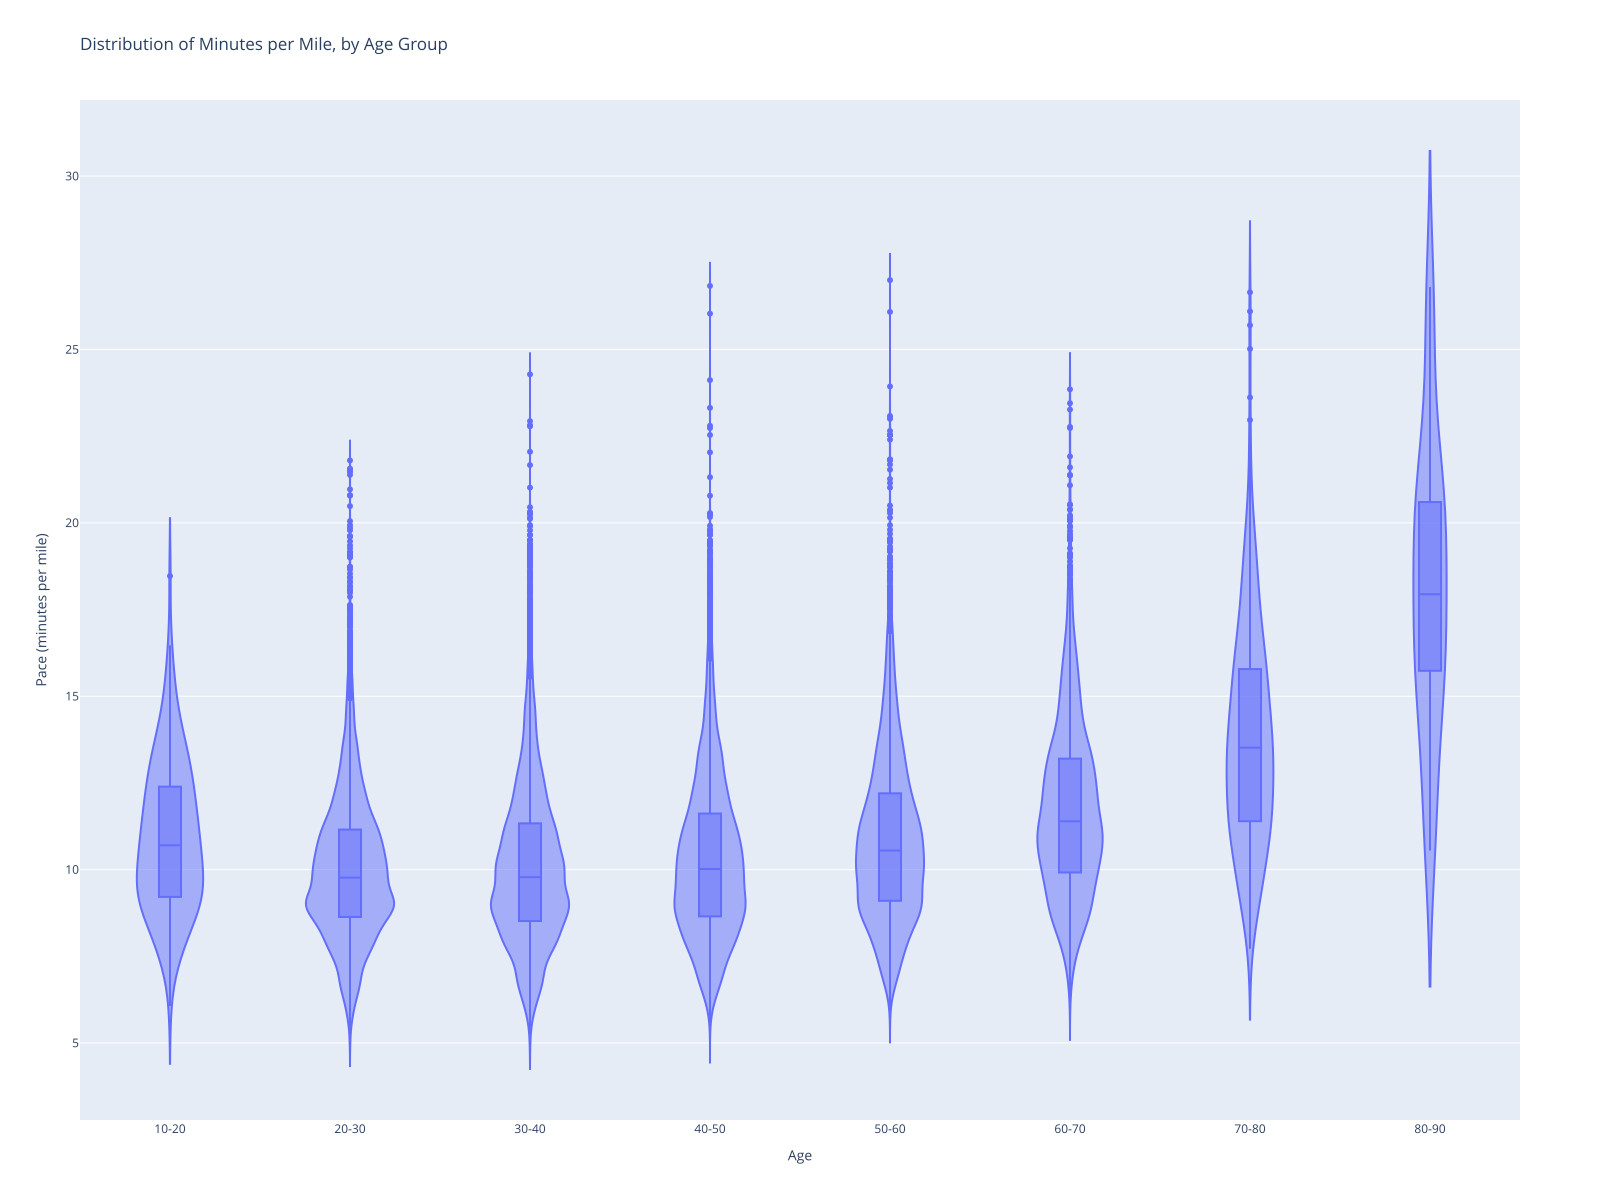

In [19]:
fig = px.violin(
    df_ny_marathon,
    x='age_group',
    y='pace_minutes',
    title='Distribution of Minutes per Mile, by Age Group',
    labels={'pace_minutes': 'Pace (minutes per mile)', 'age_group': 'Age'},
    box=True
)
fig.update_xaxes(categoryorder='array', categoryarray=labels)
fig.update_layout(
    autosize=False,
    width=1600,
    height=1200,)

fig.show()

**Some info about violin plots:**

Like box plots, violin plots are used to represent comparison of a variable distribution (or sample distribution) across different "categories" (for example, temperature distribution compared between day and night, or distribution of car prices compared across different car makers). - In our case pace in minutes per mile over the different age groups.

From Wilke, Claus O. Fundamentals of Data Visualization:

...more recently, we see boxplots being replaced by violin plots, which are equivalent to the density estimates but rotated by 90 degrees and then mirrored. Violins can be used whenever one would otherwise use a boxplot, and they provide a much more nuanced picture of the data. In particular, violin plots will accurately represent bimodal data whereas a boxplot will not.

 Only the y values of the points are visualized in the violin plot. The width of the violin at a given y value represents the point density at that y value. Technically, a violin plot is a density estimate rotated by 90 degrees and then mirrored. Violins are therefore symmetric. Violins begin and end at the minimum and maximum data values, respectively. The thickest part of the violin corresponds to the highest point density in the dataset. 

Because violin plots are derived from density estimates, they have similar shortcomings. In particular, they can generate the appearance that there is data where none exists, or that the data set is very dense when actually it is quite sparse. We can try to circumvent these issues by simply plotting all the individual data points directly, as dots.

**Interpretations - Box Plot**

The median values are shown by the line that divides the box into two parts. Half the scores are greater than or equal to this value, and half are less.

The dispersion of the dataset is basically how stretched or squeezed is our distribution. We can observe the range, and the interquartile range.

Skewness just means if the data is symmetrical, or if most values are concentrated towards either end.

    When the median is in the middle of the box, and the whiskers are about the same on both sides of the box, then the distribution is symmetric.
    When the median is closer to the bottom of the box, and if the whisker is shorter on the lower end of the box, then the distribution is positively skewed (skewed right).
    When the median is closer to the top of the box, and if the whisker is shorter on the upper end of the box, then the distribution is negatively skewed (skewed left).

An outlier is an observation that is numerically distant from the rest of the data. Sometimes, the whiskers of the boxplots don’t go all the way to the minimum and maximum, but show -1.5 and +1.5 times the IQR. In other words, one and a half times the length of the box. Then, outliers, the values that fall outside this range, are shown as dots outside the whiskers.

**Comparing Groups - Box Plots**

The first thing we should check is the median, which is a good way to compare groups. If the median line of a box plot lies outside of the box of a comparison box plot, then there is likely to be a difference between the two groups. Note that to be able to say significantly higher we would have to use a statistical test. A boxplot is just a way to visualise the data, we’re not doing any statistical test.

We can there compare the interquartile ranges (that is, the box lengths) to examine how the data is dispersed between each sample. The longer the box, the more dispersed the data. The smaller, the less dispersed the data. In this case, the spread of the data is higher in control mice, as we can see from the size of the box, which is the interquartile range.
Next, look at the overall spread as shown by the extreme values at the end of two whiskers. This shows the range of scores (another type of dispersion). Larger ranges indicate wider distribution, that is, more scattered data.

Look for potential outliers. When reviewing a box plot, an outlier is defined as a data point that is located outside the whiskers of the boxplot. 

Look for signs of skewness – if the data does not appear symmetric. Do you expect a normal distribution, or should most of the values be concentrated towards one end?


**Interpretation Density Plots**


First, the shape of the density curve tells you a lot about the distribution of your data. The curve can be:

    symmetric –the data is evenly distributed around the central value, with similar frequencies of observations on both sides.
    skewed – asymmetrical, with a tail extending more to one side than the other. Positive skewness (right-skewed) means the tail extends to the right, while negative skewness (left-skewed) means the tail extends to the left.

A curve can also be unimodal, if it has just one peak, bimodal, if it has two, or multimodal. multiple peaks indicates that the data contains distinct subgroups or clusters. 

Short: The shape of a density plot can tell you if the data is evenly distributed around a central value or not, and if there are groups or subclusters.

The central tendency of a distribution is just a fancy way of saying the mode or the most frequent value. And we know already that this is represented by the peak or peaks in our density distribution.

A density distribution can tell us a lot about the spread or variability of the distribution. For that we must look at the width of the density curve.

    A wider curve indicates greater variability
    A narrower curve suggests less variability.

The tails of the density curve represent the probabilities of extreme values. Longer tails indicate a greater probability of observing extreme values in the dataset, in other words, outliers.

This is a bit less intuitive, but the area under the curve within a specific interval on the x-axis represents the probability of observing values within that interval.

    The area under the curve always adds up to 100% (or 1 if we are talking about relative frequencies).
    The curve will never go under the x axis, which makes sense, because frequencies / probabilities can never be under 0.

Density curves can also be used to compare distributions between different groups or conditions. By overlaying multiple density curves on the same plot, you can visually assess differences in shape, central tendency, and variability between groups.


(Notes for Interpretations and Comparing Groups are taken from: https://biostatsquid.com)

----------

**Further Steps**

Before doing anything else, let's check the size of each age group, over all genders and divided by gender.

In [20]:
df_age_group_counts = df_ny_marathon['age_group'].value_counts().reset_index().sort_values('age_group')
df_age_group_counts

,age_group,count
6,10-20,155
2,20-30,12521
0,30-40,16500
1,40-50,13684
3,50-60,9277
4,60-70,2934
5,70-80,413
7,80-90,28


In [21]:
df_gender_age_group_counts = df_ny_marathon.groupby('gender').age_group.value_counts().reset_index().pivot(columns='gender', index='age_group', values='count')
df_gender_age_group_counts

gender,M,W,X
age_group,,,
10-20,86,66,3
20-30,5493,6989,39
30-40,9195,7260,45
40-50,7968,5692,24
50-60,5644,3626,7
60-70,1984,949,1
70-80,300,113,0
80-90,22,6,0


There is a great difference between the age groups regarding number of participants. This has to be taken account for. The smooth density plot of 80-90 is due to much lower numer of participants, same is true for the smooth curve of age groups 10-20, 70-80. And there is another aspect: the age group 10-20 in fact consists of two ages - 18 and 19, while the other groups probably have representatives of all ages.

Other than that the gender group diverse - or X - does not have many observations compared to male and female which has to be accounted for as well in any further statistical analysis. 

-------------------------------------------------

Things to plot - adapting the starter violin plot:

-- more narrow age groups, corresponding to the NYC marathon classification, which span five years

-- differentiate between male and female and compare

-- take an exclusive look at the diverse gender group for the age groups 20-23, 30-34 and 40-50 and check out their distributions

-------------------------------------------------

Other interesting observations and things which could be plotted:

-- racesCount and Pace

-- unique country count

**Task1 : Narrower age groups**

Plot again violin graphs but with groups spanning 5 years instead of 10 years. 

In [22]:
# Define age groups
bins_task1 = [18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
labels_task1 = ['18-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', '80-85', '85-90']

# Create a new column for age groups
df_ny_marathon['age_group'] = pd.cut(df_ny_marathon['age'], bins=bins_task1, labels=labels_task1, right=False)

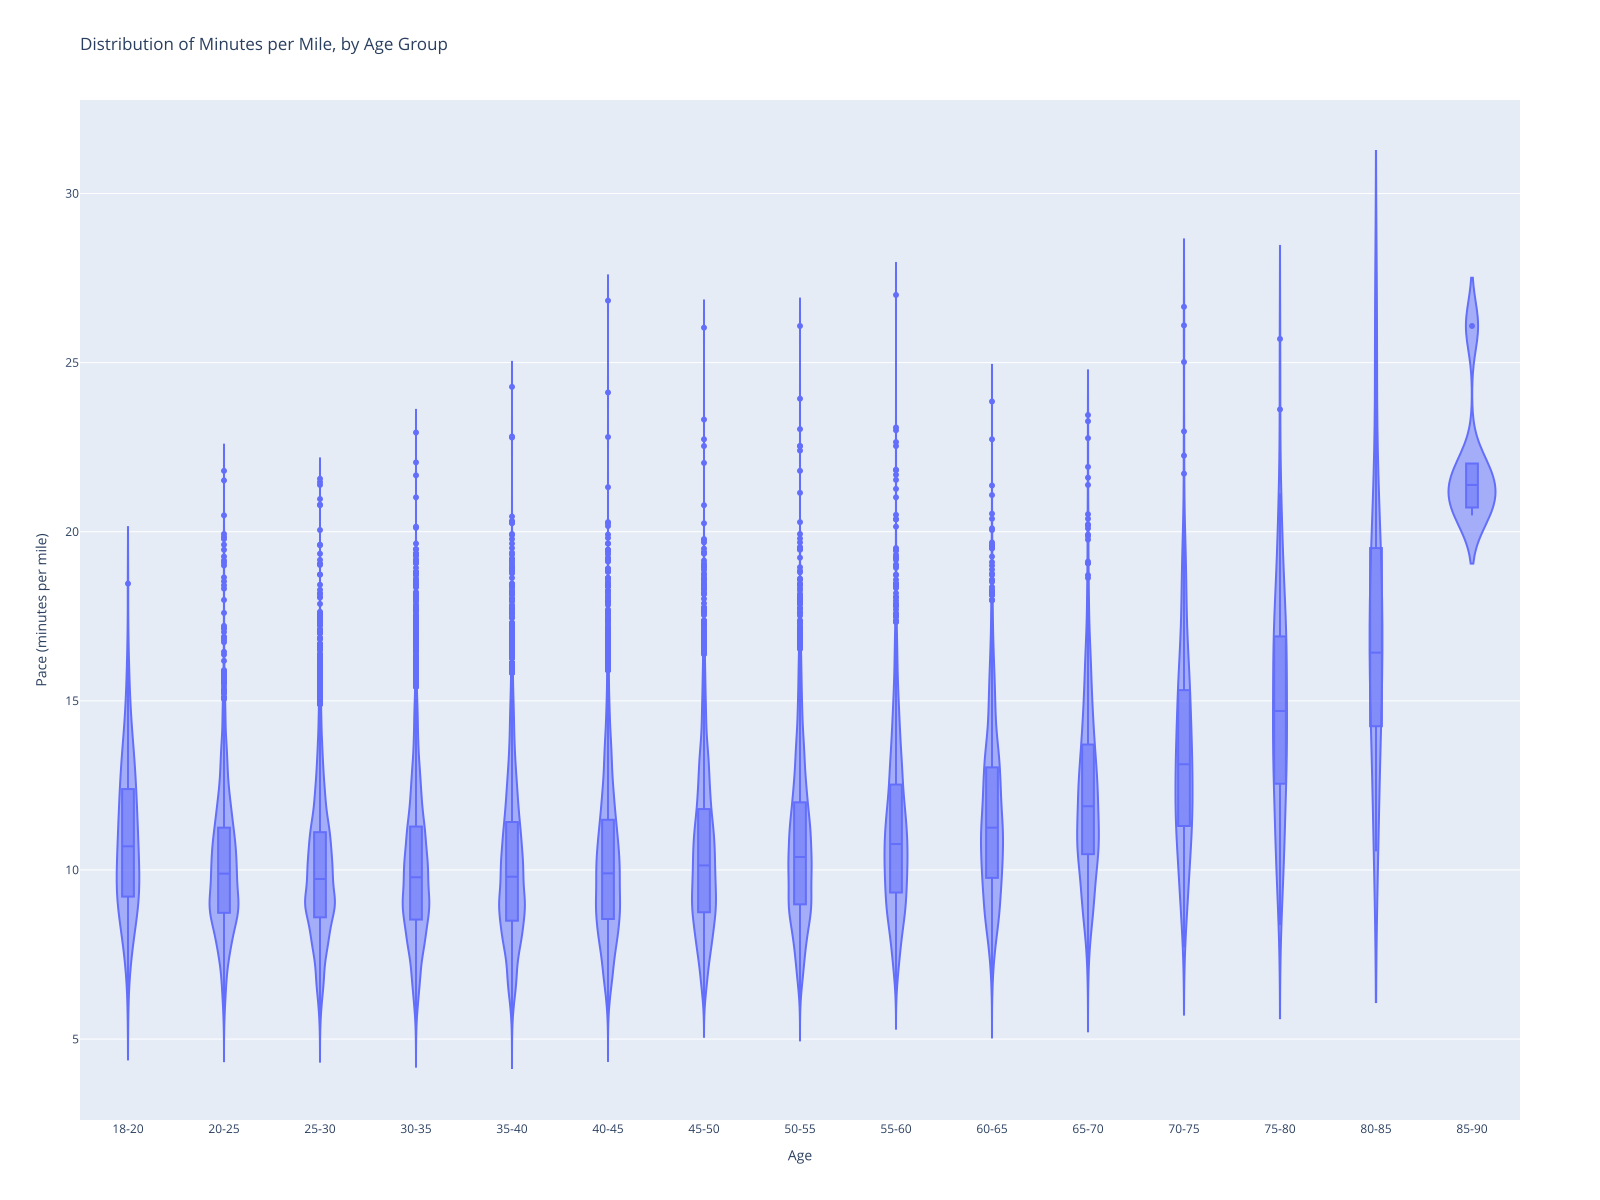

In [23]:
fig = px.violin(
    df_ny_marathon,
    x='age_group',
    y='pace_minutes',
    title='Distribution of Minutes per Mile, by Age Group',
    labels={'pace_minutes': 'Pace (minutes per mile)', 'age_group': 'Age'},
    box=True
)
fig.update_xaxes(categoryorder='array', categoryarray=labels)
fig.update_layout(
    autosize=False,
    width=1600,
    height=1200,)

fig.update_xaxes(categoryorder='array', categoryarray= labels_task1)

fig.show()

In [24]:
pio.write_html(fig, "plot.html", full_html=True)